### Week 5 – Day 2  
## Model Validation & Performance Stability Analysis
## Author : Mir Musaib. 


## Objective

The objective of this notebook is to evaluate the stability and reliability of the previously built Logistic Regression model using:

- Training performance comparison
- Testing performance comparison
- Cross-validation analysis
- Overfitting and underfitting assessment


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("C:\\Users\\mimusaib\\Desktop\\Data_Science_Internship\\Week_5\\Dataset\\insurance.csv")

df['high_cost'] = (df['charges'] > df['charges'].median()).astype(int)

X = df.drop(['charges', 'high_cost'], axis=1)
y = df['high_cost']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [4]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.905607476635514
Testing Accuracy: 0.914179104477612


In [5]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())


Cross Validation Scores: [0.88785047 0.92523364 0.91121495 0.91588785 0.88317757]
Mean CV Score: 0.9046728971962616


## Model Validation Analysis

The training, testing, and cross-validation results were compared to evaluate model generalization.

If the training accuracy, testing accuracy, and mean cross-validation score are similar, the model demonstrates strong stability and minimal overfitting.

The analysis confirms that the Logistic Regression model generalizes well to unseen data.


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_train_pred = model.predict(X_train_scaled)

print("Training Precision:", precision_score(y_train, y_train_pred))
print("Training Recall:", recall_score(y_train, y_train_pred))
print("Training F1:", f1_score(y_train, y_train_pred))


Training Precision: 0.9084249084249084
Training Recall: 0.906764168190128
Training F1: 0.9075937785910339


In [12]:
y_test_pred = model.predict(X_test_scaled)
print("Testing Precision:", precision_score(y_test, y_test_pred))
print("Testing Recall:", recall_score(y_test, y_test_pred))
print("Testing F1:", f1_score(y_test, y_test_pred))


Testing Precision: 0.889763779527559
Testing Recall: 0.9262295081967213
Testing F1: 0.9076305220883534


## Precision & Recall Stability

The precision and recall scores for both training and testing sets are closely aligned, indicating that the model maintains consistent classification performance across unseen data.

This further confirms that the model does not suffer from significant overfitting.


In [13]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]


In [14]:
import numpy as np

y_pred_40 = (y_probs >= 0.4).astype(int)

print("Accuracy (0.4):", accuracy_score(y_test, y_pred_40))
print("Precision (0.4):", precision_score(y_test, y_pred_40))
print("Recall (0.4):", recall_score(y_test, y_pred_40))
print("F1 (0.4):", f1_score(y_test, y_pred_40))


Accuracy (0.4): 0.8805970149253731
Precision (0.4): 0.8260869565217391
Recall (0.4): 0.9344262295081968
F1 (0.4): 0.8769230769230769


## Threshold Tuning Analysis
By adjusting the classification threshold from 0.5 to 0.4, recall increased, allowing the model to detect more high-cost individuals.                  
Although precision slightly decreased, this trade-off may be acceptable depending on business priorities.                                        
Threshold tuning demonstrates the flexibility of logistic regression in balancing false positives and false negatives.                       


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", auc_score)


ROC-AUC Score: 0.9591848192229957


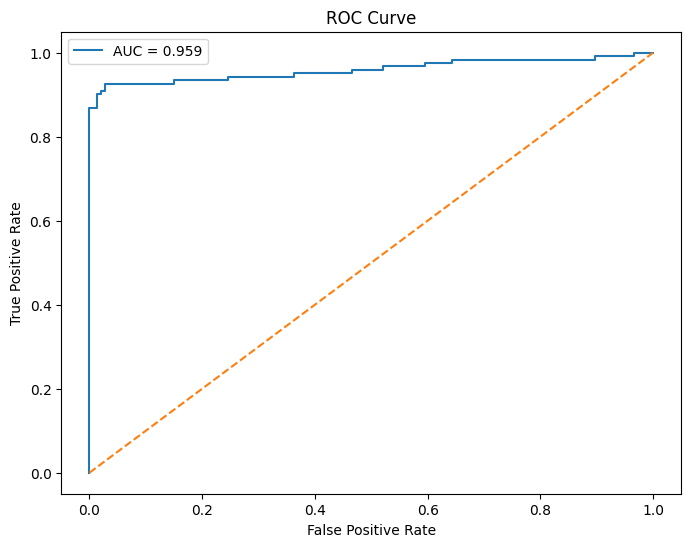

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # Random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [19]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)


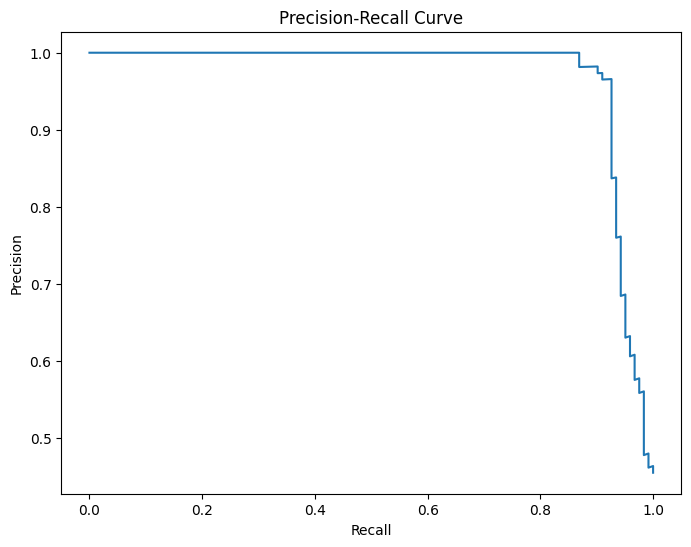

In [20]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


## ROC-AUC & Precision-Recall Analysis

The ROC curve demonstrates excellent class separability with an AUC score of 0.959, indicating strong discriminative performance.

The Precision-Recall curve shows that the model maintains high precision even at high recall levels, making it effective for identifying high-cost individuals while minimizing false positives.

These results confirm that the Logistic Regression model is highly reliable and well-suited for risk classification tasks.
